In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.finite_element_1D import Domains1D, FiniteElement1D, QHOBasis1D, TaperedQHOBasis1D, SmoothBumpQHOBasis1D

In [218]:
domain = Domains1D([-2], [2])
element_num = 1
rank = 16
res = 1000
points = np.linspace(-2, 2, 1001)

In [219]:
fe_qho = FiniteElement1D.from_uniform_grid(domain, element_num, QHOBasis1D, rank, res)
fe_tho = FiniteElement1D.from_uniform_grid(domain, element_num, TaperedQHOBasis1D, rank, res)
fe_sho = FiniteElement1D.from_uniform_grid(domain, element_num, SmoothBumpQHOBasis1D, rank, res)

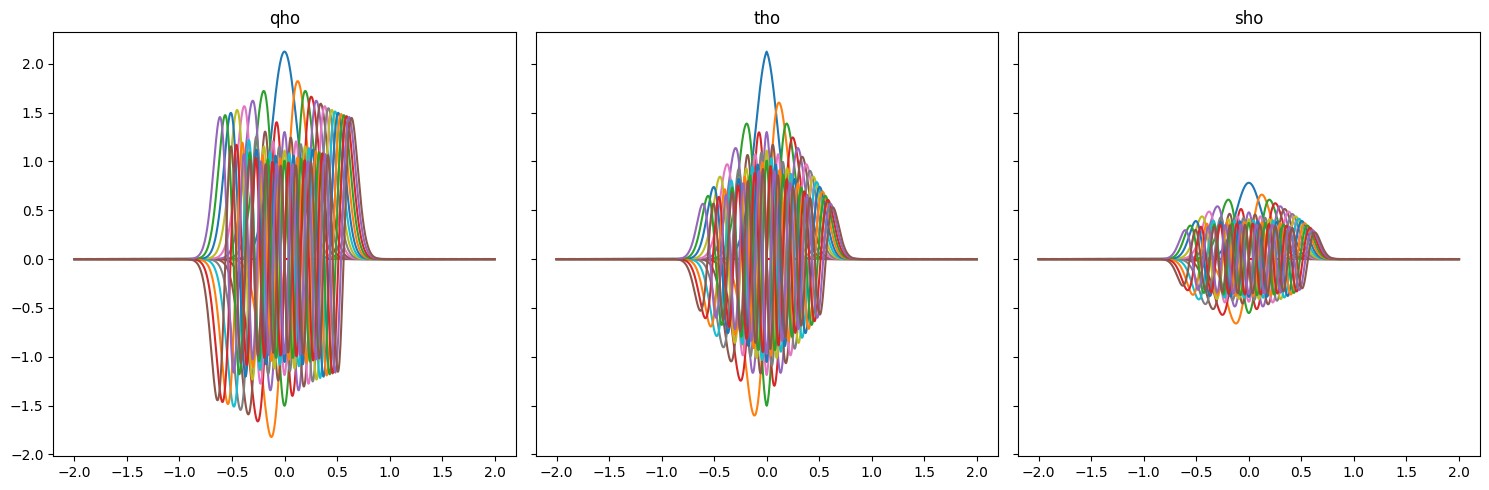

In [220]:
fig, axs = plt.subplots(1, 3, sharex = True, sharey = True, figsize = (15, 5))
for i, (f, label) in enumerate(zip([fe_qho.basis.get_fun(Domains1D(-1, 1)), fe_tho.basis.get_fun(Domains1D(-1, 1)), fe_sho.basis.get_fun(Domains1D(-1, 1))], ['qho', 'tho', 'sho'])):
    axs[i].plot(points, points * 0, 'r--')
    axs[i].plot(points, f(points))
    axs[i].title.set_text(label)
fig.tight_layout()
fig.show()

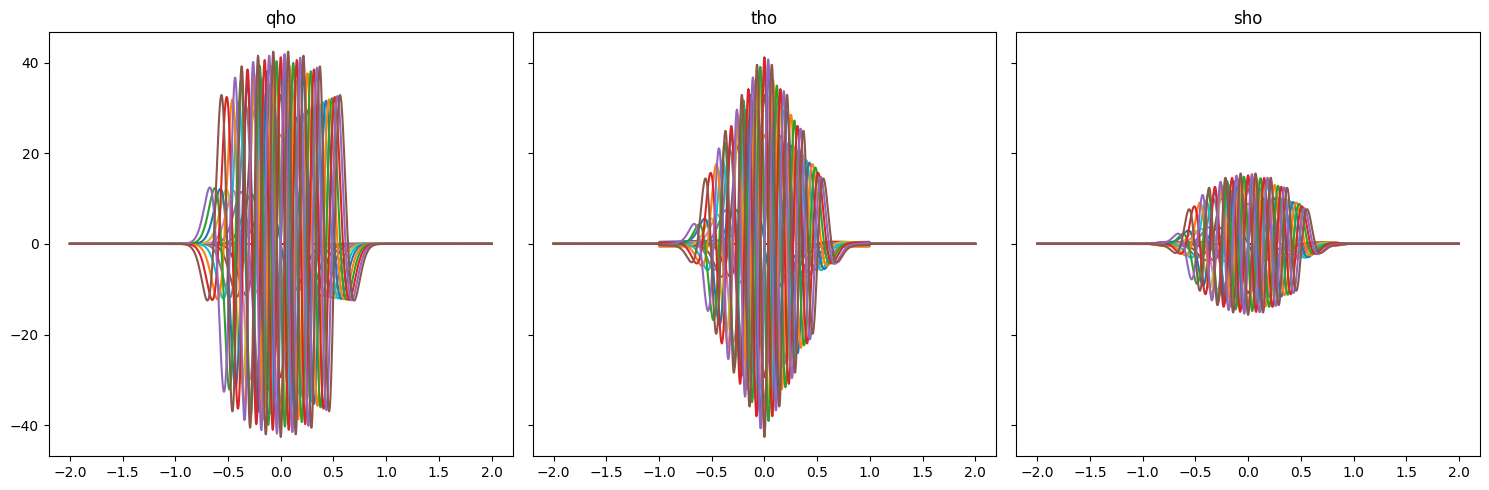

In [221]:
fig, axs = plt.subplots(1, 3, sharex = True, sharey = True, figsize = (15, 5))
for i, (f, label) in enumerate(zip([fe_qho.basis.get_der(Domains1D(-1, 1)), fe_tho.basis.get_der(Domains1D(-1, 1)), fe_sho.basis.get_der(Domains1D(-1, 1))], ['qho', 'tho', 'sho'])):
    axs[i].plot(points, points * 0, 'r--')
    axs[i].plot(points, f(points))
    axs[i].title.set_text(label)
fig.tight_layout()
fig.show()

In [230]:
fun = lambda x: x#np.exp(-2*x**2)
rep_qho = fe_qho.basis.fun2rep(fun)
rep_tho = fe_tho.basis.fun2rep(fun)
rep_sho = fe_sho.basis.fun2rep(fun)

fun_rep_qho = fe_qho.basis.rep2fun(rep_qho)
fun_rep_tho = fe_tho.basis.rep2fun(rep_tho)
fun_rep_sho = fe_sho.basis.rep2fun(rep_sho)

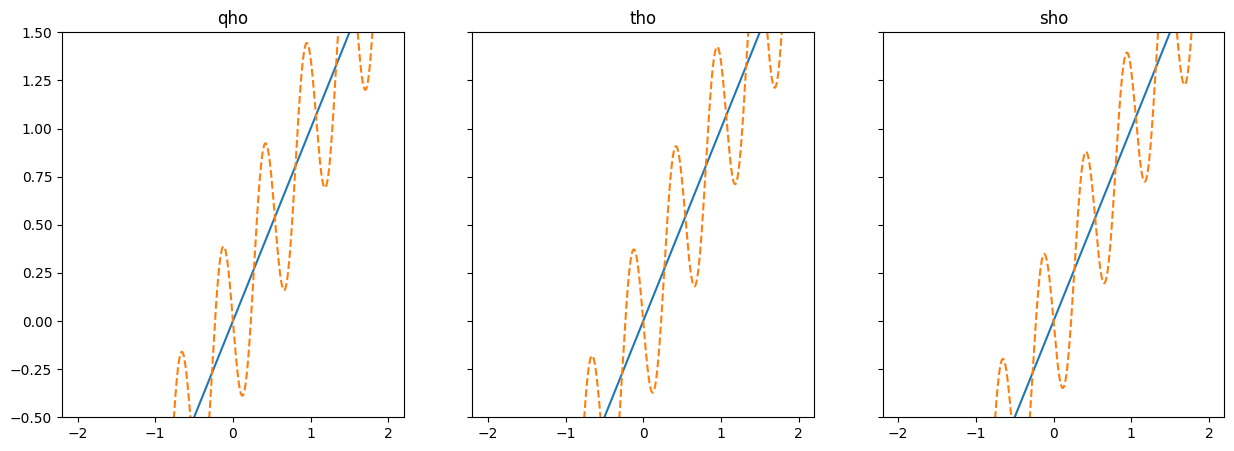

In [231]:
fig, axs = plt.subplots(1, 3, sharex = True, sharey = True, figsize = (15, 5))
for i, (f, label) in enumerate(zip([fun_rep_qho, fun_rep_tho, fun_rep_sho], ['qho', 'tho', 'sho'])):
    axs[i].plot(points, fun(points))
    axs[i].plot(points, f(points), '--')
    axs[i].title.set_text(label)
axs[0].set_ylim(-0.5, 1.5)
fig.show()

In [232]:
fun_prime = lambda x: np.exp(-2*x**2) * -4 * x

rep_prime_qho = fe_qho.basis.diff(rep_qho)
rep_prime_tho = fe_tho.basis.diff(rep_tho)
rep_prime_sho = fe_sho.basis.diff(rep_sho)

fun_rep_prime_qho = fe_qho.basis.rep2fun(rep_prime_qho)
fun_rep_prime_tho = fe_tho.basis.rep2fun(rep_prime_tho)
fun_rep_prime_sho = fe_sho.basis.rep2fun(rep_prime_sho)

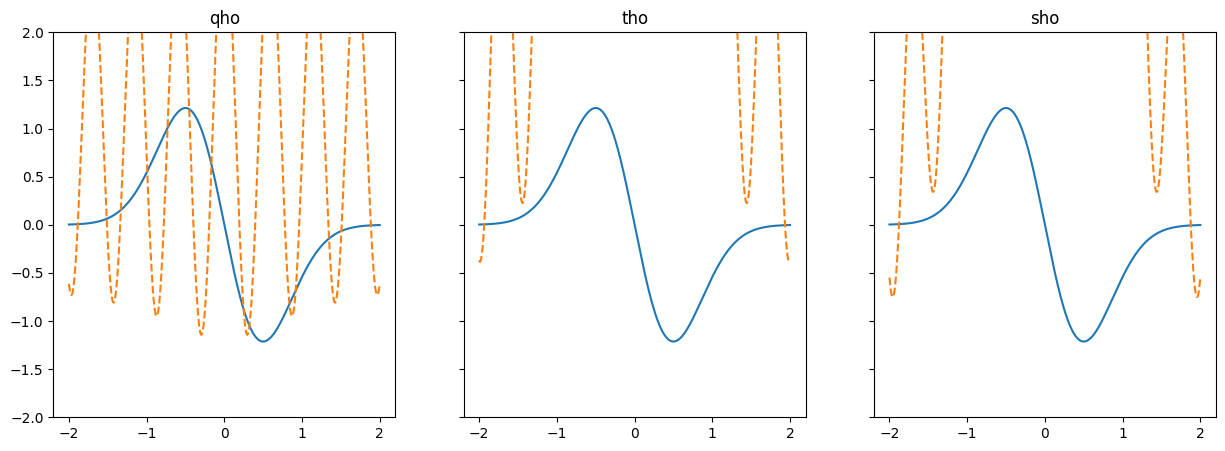

In [233]:
fig, axs = plt.subplots(1, 3, sharex = True, sharey = True, figsize = (15, 5))
for i, (f, label) in enumerate(zip([fun_rep_prime_qho, fun_rep_prime_tho, fun_rep_prime_sho], ['qho', 'tho', 'sho'])):
    axs[i].plot(points, fun_prime(points))
    axs[i].plot(points, f(points), '--')
    axs[i].title.set_text(label)
axs[0].set_ylim(-2, 2)
fig.show()

In [226]:
fun_prime2 = lambda x: 4 * (4 * x ** 2 - 1) * np.exp(-2*x**2)

rep_prime2_qho = fe_qho.basis.diff(rep_prime_qho)
rep_prime2_tho = fe_tho.basis.diff(rep_prime_tho)
rep_prime2_sho = fe_sho.basis.diff(rep_prime_sho)

fun_rep_prime2_qho = fe_qho.basis.rep2fun(rep_prime2_qho)
fun_rep_prime2_tho = fe_tho.basis.rep2fun(rep_prime2_tho)
fun_rep_prime2_sho = fe_sho.basis.rep2fun(rep_prime2_sho)

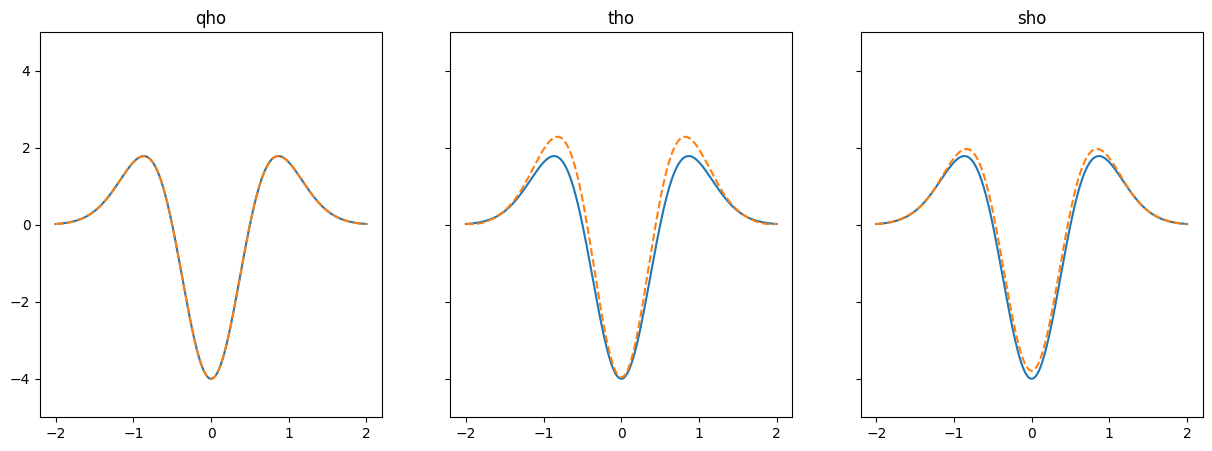

In [227]:
fig, axs = plt.subplots(1, 3, sharex = True, sharey = True, figsize = (15, 5))
for i, (f, label) in enumerate(zip([fun_rep_prime2_qho, fun_rep_prime2_tho, fun_rep_prime2_sho], ['qho', 'tho', 'sho'])):
    axs[i].plot(points, fun_prime2(points))
    axs[i].plot(points, f(points), '--')
    axs[i].title.set_text(label)
axs[0].set_ylim(-5, 5)
fig.show()

In [228]:
fun_prime3 = lambda x: -16 * x * (4 * x ** 2 - 3) * np.exp(-2*x**2)

rep_prime3_qho = fe_qho.basis.diff(rep_prime2_qho)
rep_prime3_tho = fe_tho.basis.diff(rep_prime2_tho)
rep_prime3_sho = fe_sho.basis.diff(rep_prime2_sho)

fun_rep_prime3_qho = fe_qho.basis.rep2fun(rep_prime3_qho)
fun_rep_prime3_tho = fe_tho.basis.rep2fun(rep_prime3_tho)
fun_rep_prime3_sho = fe_sho.basis.rep2fun(rep_prime3_sho)

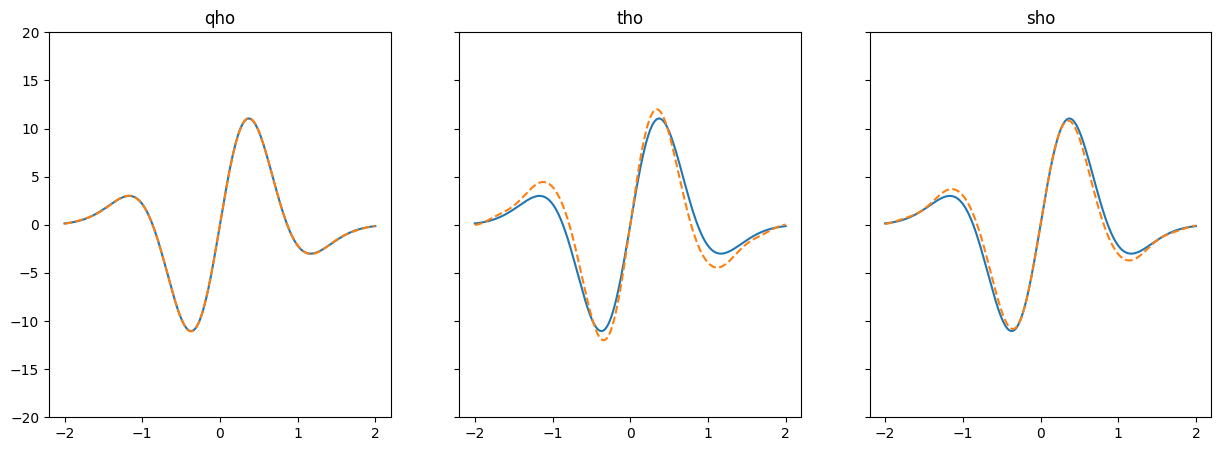

In [229]:
fig, axs = plt.subplots(1, 3, sharex = True, sharey = True, figsize = (15, 5))
for i, (f, label) in enumerate(zip([fun_rep_prime3_qho, fun_rep_prime3_tho, fun_rep_prime3_sho], ['qho', 'tho', 'sho'])):
    axs[i].plot(points, fun_prime3(points))
    axs[i].plot(points, f(points), '--')
    axs[i].title.set_text(label)
axs[0].set_ylim(-20, 20)
fig.show()